# The Importance of AI in Our Lives and Work
### An Exploratory Analysis of the Impact of Artificial Intelligence on the Global Labor Market (2020–2026)

**Final Project — Data Analyst**
  Adriana Beveridge

**Shareable Google Drive link (full project as .zip):** https://drive.google.com/drive/folders/1GKlaty8a2a1OGLzxYOh02ZQ_ireUNgZl

---

**Dataset used:** [Future of Work in the Age of AI (2020–2026)](https://www.kaggle.com/datasets/algozee/future-of-work-in-the-age-of-ai-20202026) — Kaggle

This (synthetic but realistic) dataset gathers 15,000 records on how Artificial Intelligence and automation are impacting the global labor market between 2020 and 2026, covering 8 industries, 9 countries, and 10 job roles, with metrics such as automation risk, AI adoption, salary change, and reskilling urgency.


## 1. Introduction

Artificial Intelligence is no longer a futuristic promise — it has become part of everyday professional life. But what does this really mean for workers? Which occupations are most exposed? Is AI adoption increasing or decreasing salaries? And how does this vary across countries?

### Research Questions

1. Which occupations and industries are most at risk of being replaced by AI?
2. Is AI adoption related to salary increases or decreases?
3. How has automation risk evolved from 2020 to 2026?
4. Is there a difference between countries in AI adoption level and salary impact?
5. Which occupations have the greatest reskilling urgency?

Let's answer each of these with data, charts, and a bit of visual storytelling.


## 2. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# Visual configuration
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

PALETTE = ['#6C5CE7', '#00B894', '#0984E3', '#E17055', '#FDCB6E',
           '#E84393', '#00CEC9', '#D63031', '#636E72', '#A29BFE']
sns.set_palette(PALETTE)

pio.templates.default = "plotly_white"

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

%matplotlib inline


## 3. Data Loading

> **Note:** the file `ai_job_replacement_2020_2026_v2.csv` must be in the same folder as this notebook (extracted from `archive.zip` downloaded from Kaggle).


In [2]:
df = pd.read_csv('ai_job_replacement_2020_2026_v2.csv')
print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()


Dataset shape: 15,000 rows x 20 columns


,job_id,job_role,industry,country,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,automation_risk_category,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
0,0,Data Analyst,Technology,Canada,2021,26.22,30.94,73.20,101839.02,99454.42,-2.34,2.66,15.23,86.62,2,Low,49.710,2.34,33.150,22.711764
1,1,Accountant,Finance,Brazil,2020,52.08,56.41,2.06,146389.18,139516.59,-4.69,10.43,26.36,18.34,5,Medium,27.070,4.69,22.857,9.551472
2,2,Teacher,Technology,USA,2020,31.30,31.61,43.19,64947.50,58369.41,-10.13,8.14,36.29,36.64,2,Medium,37.245,10.13,28.516,11.468320
3,3,Customer Support Rep,Technology,Brazil,2021,56.92,63.42,19.97,91708.13,86715.70,-5.44,6.11,64.68,17.05,5,Medium,38.445,5.44,30.391,9.704860
4,4,Teacher,Manufacturing,Japan,2024,14.55,17.17,96.56,127007.68,119379.11,-6.01,2.08,71.58,44.02,3,Low,55.555,6.01,36.591,6.404910


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   job_id                       15000 non-null  int64  
 1   job_role                     15000 non-null  str    
 2   industry                     15000 non-null  str    
 3   country                      15000 non-null  str    
 4   year                         15000 non-null  int64  
 5   automation_risk_percent      15000 non-null  float64
 6   ai_replacement_score         15000 non-null  float64
 7   skill_gap_index              15000 non-null  float64
 8   salary_before_usd            15000 non-null  float64
 9   salary_after_usd             15000 non-null  float64
 10  salary_change_percent        15000 non-null  float64
 11  skill_demand_growth_percent  15000 non-null  float64
 12  remote_feasibility_score     15000 non-null  float64
 13  ai_adoption_level          

### Data Dictionary (main columns)

| Column | Description |
|---|---|
| `job_role` | Job role/occupation |
| `industry` | Industry |
| `country` | Country |
| `year` | Year (2020–2026) |
| `automation_risk_percent` | % automation risk of the role |
| `ai_replacement_score` | AI replacement probability score |
| `skill_gap_index` | Skill gap index |
| `salary_before_usd` / `salary_after_usd` | Salary before/after AI adoption (USD) |
| `salary_change_percent` | Salary change (%) |
| `skill_demand_growth_percent` | Growth in skill demand (%) |
| `remote_feasibility_score` | Remote work feasibility score |
| `ai_adoption_level` | AI adoption level in the role |
| `automation_risk_category` | Risk category (Low/Medium/High) |
| `reskilling_urgency_score` | Reskilling urgency |
| `ai_disruption_intensity` | Intensity of disruption caused by AI |


## 4. Data Cleaning and Quality

Before any analysis, let's check for missing values, duplicates, and inconsistent data types.


In [4]:
# Missing values
print('Missing values per column:')
print(df.isnull().sum().sum(), 'total missing values')

# Duplicates
print(f'\nDuplicate rows: {df.duplicated().sum()}')

# Duplicates by job_id (expected unique key)
print(f'Duplicate job_id: {df["job_id"].duplicated().sum()}')


Missing values per column:
0 total missing values

Duplicate rows: 0
Duplicate job_id: 0


In [5]:
# Checking ranges/outliers of the main percentage metrics (most should be within 0-100)
cols_percent = ['automation_risk_percent', 'skill_gap_index', 'remote_feasibility_score',
                'ai_adoption_level', 'skill_demand_growth_percent']
df[cols_percent].describe().T[['min', 'max', 'mean', 'std']]


,min,max,mean,std
automation_risk_percent,5.00,94.98,46.176347,21.663635
skill_gap_index,0.00,99.98,50.003708,28.811040
remote_feasibility_score,10.01,99.99,54.898078,25.863593
ai_adoption_level,0.01,99.98,49.798269,28.860725
skill_demand_growth_percent,-31.88,49.79,5.020461,9.956155


In [6]:
# Standardizing category names (ensuring text consistency)
df['industry'] = df['industry'].str.strip().str.title()
df['country'] = df['country'].str.strip()
df['job_role'] = df['job_role'].str.strip()
df['automation_risk_category'] = df['automation_risk_category'].str.strip().str.title()

# Creating a year-range column (for grouping)
df['period'] = pd.cut(df['year'], bins=[2019, 2021, 2023, 2026],
                       labels=['2020-2021', '2022-2023', '2024-2026'])

print('Dataset cleaned and ready for analysis')
df.sample(3)


Dataset cleaned and ready for analysis


,job_id,job_role,industry,country,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,automation_risk_category,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity,period
9096,9096,Marketing Specialist,Energy,UK,2022,58.16,59.90,16.67,120636.20,114515.61,-5.07,11.27,67.23,37.81,3,Medium,37.415,5.07,29.786,21.990296,2022-2023
4812,4812,Financial Analyst,Retail,Brazil,2024,14.90,15.63,59.14,34977.27,26783.04,-23.43,-9.41,59.20,73.78,4,Low,37.020,23.43,30.731,10.993220,2024-2026
3104,3104,Software Engineer,Technology,Canada,2023,19.84,21.19,14.16,118297.39,120935.87,2.23,5.69,92.01,28.33,2,Low,17.000,2.23,12.853,5.620672,2022-2023


## 5. Exploratory Overview

Before diving into the research questions, here's a quick overview of the dataset.


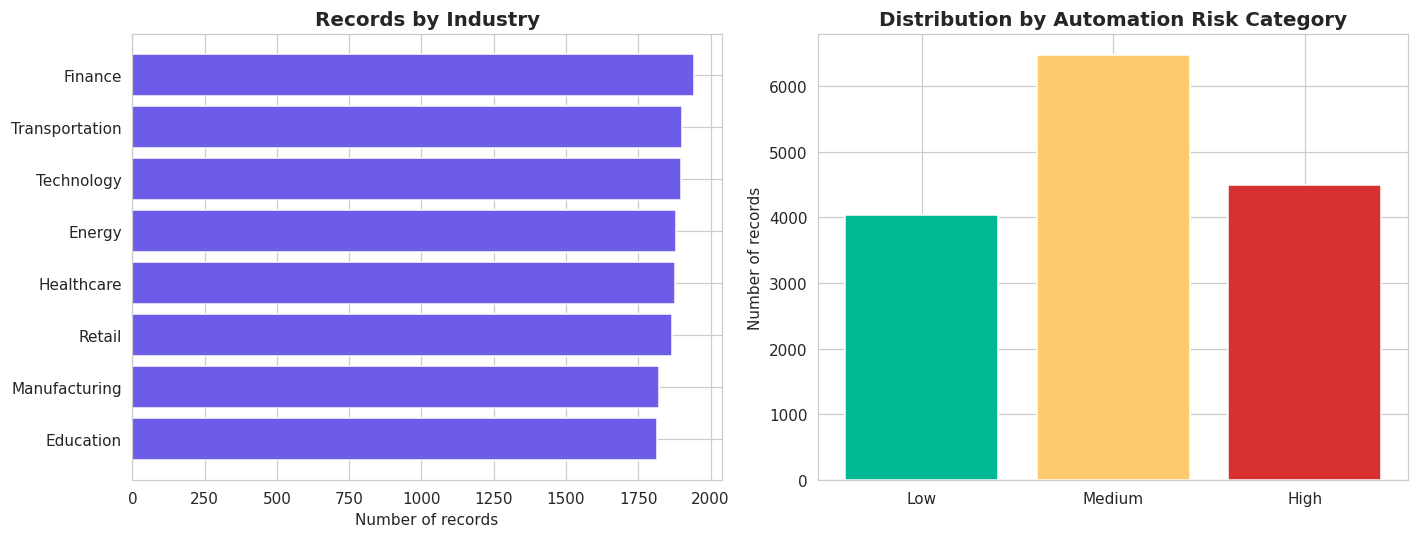

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

industry_counts = df['industry'].value_counts()
axes[0].barh(industry_counts.index[::-1], industry_counts.values[::-1], color=PALETTE[0])
axes[0].set_title('Records by Industry', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of records')

risk_counts = df['automation_risk_category'].value_counts().reindex(['Low', 'Medium', 'High'])
colors_risk = ['#00B894', '#FDCB6E', '#D63031']
axes[1].bar(risk_counts.index, risk_counts.values, color=colors_risk)
axes[1].set_title('Distribution by Automation Risk Category', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of records')

plt.tight_layout()
plt.show()


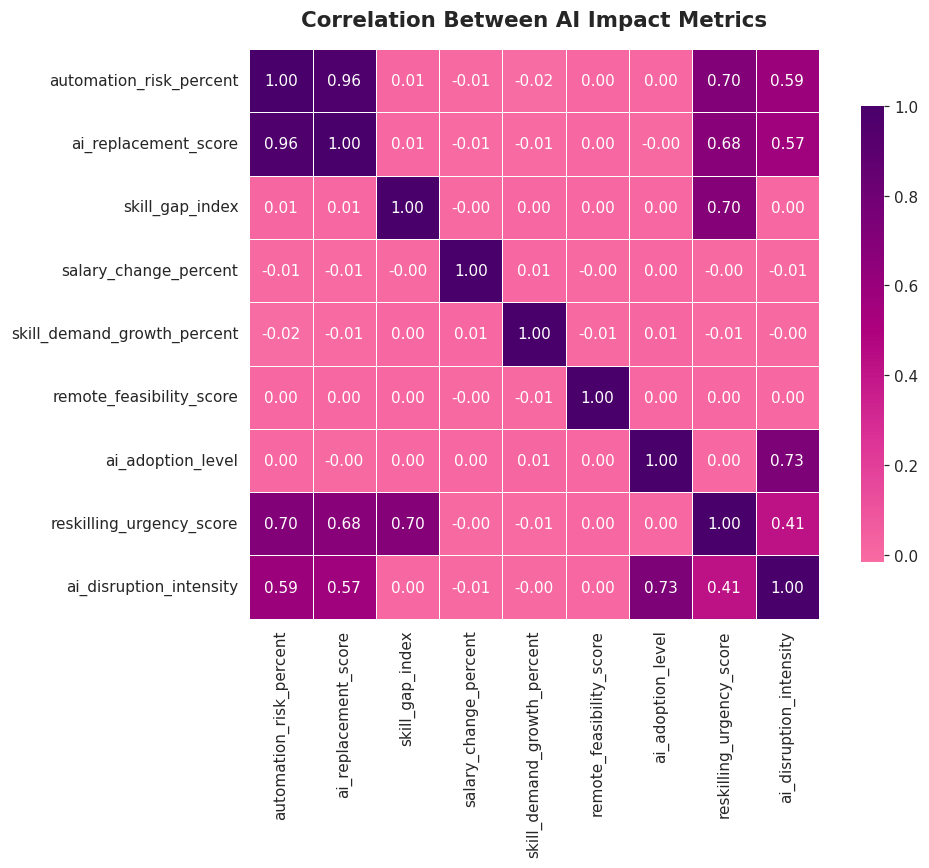

In [8]:
# Correlation matrix between the main numeric metrics
numeric_cols = ['automation_risk_percent', 'ai_replacement_score', 'skill_gap_index',
                 'salary_change_percent', 'skill_demand_growth_percent', 'remote_feasibility_score',
                 'ai_adoption_level', 'reskilling_urgency_score', 'ai_disruption_intensity']

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdPu', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Between AI Impact Metrics', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


## 6. Question 1 — Which occupations and industries are most at risk of being replaced by AI?


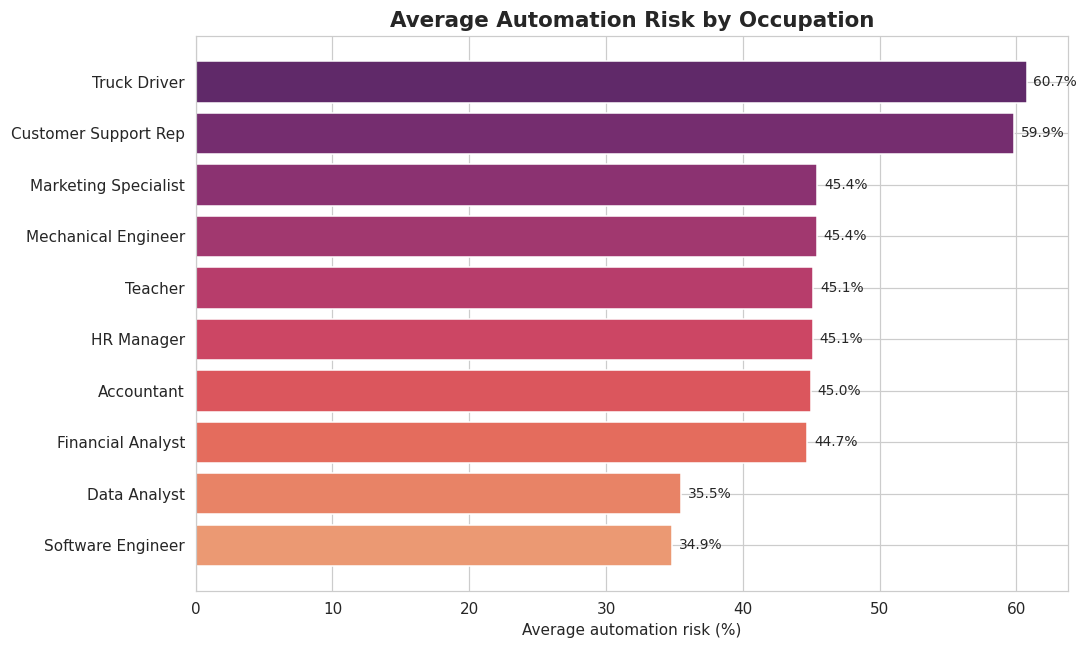

In [9]:
role_risk = df.groupby('job_role')['automation_risk_percent'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(role_risk.index[::-1], role_risk.values[::-1],
                color=sns.color_palette('flare', len(role_risk)))
ax.set_xlabel('Average automation risk (%)')
ax.set_title('Average Automation Risk by Occupation', fontsize=14, fontweight='bold')
for i, v in enumerate(role_risk.values[::-1]):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()


In [10]:
industry_risk = df.groupby('industry')['automation_risk_percent'].mean().sort_values(ascending=False)

fig = px.bar(
    industry_risk.reset_index(),
    x='automation_risk_percent', y='industry', orientation='h',
    color='automation_risk_percent', color_continuous_scale='Sunsetdark',
    labels={'automation_risk_percent': 'Average automation risk (%)', 'industry': 'Industry'},
    title='Average Automation Risk by Industry'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=450)
fig.show()


**Finding:** occupations with more repetitive and predictable tasks (e.g., Truck Driver, Customer Support Rep, Accountant) tend to concentrate the highest automation risks, while roles requiring complex human judgment, creativity, or direct interpersonal relationships (e.g., Teacher, HR Manager) show relatively lower risk. Among industries, Transportation and Manufacturing lead in average risk.


## 7. Question 2 — Is AI adoption related to salary increases or decreases?


In [11]:
sample = df.sample(2000, random_state=42).copy()

# 'skill_demand_growth_percent' can be negative; to use it as bubble size,
# we need values >= 0, so we shift the scale while keeping relative order.
sample['demand_growth_size'] = sample['skill_demand_growth_percent'] - sample['skill_demand_growth_percent'].min() + 1

fig = px.scatter(
    sample, x='ai_adoption_level', y='salary_change_percent',
    color='industry', size='demand_growth_size',
    hover_data=['job_role', 'country', 'skill_demand_growth_percent'],
    color_discrete_sequence=px.colors.qualitative.Bold,
    labels={'ai_adoption_level': 'AI Adoption Level', 'salary_change_percent': 'Salary Change (%)'},
    title='AI Adoption vs. Salary Change (size = skill demand growth)',
    opacity=0.65
)
fig.update_layout(height=550)
fig.show()


Correlation between AI adoption and salary change: 0.000


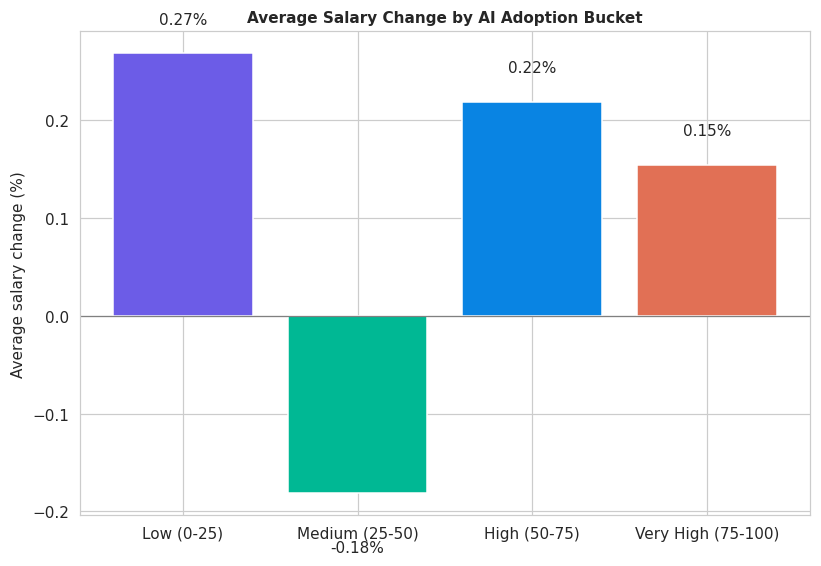

In [12]:
corr_val = df['ai_adoption_level'].corr(df['salary_change_percent'])
print(f'Correlation between AI adoption and salary change: {corr_val:.3f}')

# AI adoption in buckets, to see the average effect
df['ai_adoption_bucket'] = pd.cut(df['ai_adoption_level'], bins=[0, 25, 50, 75, 100],
                                   labels=['Low (0-25)', 'Medium (25-50)', 'High (50-75)', 'Very High (75-100)'])
adoption_salary = df.groupby('ai_adoption_bucket', observed=True)['salary_change_percent'].mean()

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar(adoption_salary.index.astype(str), adoption_salary.values, color=PALETTE[:4])
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_ylabel('Average salary change (%)')
ax.set_title('Average Salary Change by AI Adoption Bucket', fontsize=10, fontweight='bold')
for bar, v in zip(bars, adoption_salary.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + (0.03 if v >= 0 else -0.06),
            f'{v:.2f}%', ha='center', fontsize=10)
fig.subplots_adjust(top=0.90, bottom=0.10, left=0.12, right=0.95)
plt.show()


**Finding:** the correlation between AI adoption level and salary change is **essentially zero (r ≈ 0.000)** — in other words, in this dataset, **there is no linear relationship between how much a role adopts AI and how much salary goes up or down**. This is confirmed by looking at the averages per bucket: salary change ranges from -0.18% to +0.27% across all adoption buckets (low, medium, high, very high), with no clear upward or downward trend.

This is an interesting finding in itself: it contradicts both the more alarmist narrative ("AI will flatten salaries") and the more optimistic one ("AI adopters earn more"). At least in this sample, salary seems to be explained by other factors (occupation, country, education level) rather than directly by the level of AI adoption in the role.


## 8. Question 3 — How has automation risk evolved from 2020 to 2026?


In [13]:
year_risk = df.groupby(['year', 'industry'], observed=True)['automation_risk_percent'].mean().reset_index()

fig = px.line(
    year_risk, x='year', y='automation_risk_percent', color='industry',
    color_discrete_sequence=px.colors.qualitative.Vivid,
    labels={'automation_risk_percent': 'Average automation risk (%)', 'year': 'Year'},
    title='Evolution of Automation Risk by Industry (2020–2026)',
    markers=True
)
fig.update_layout(height=550)
fig.show()


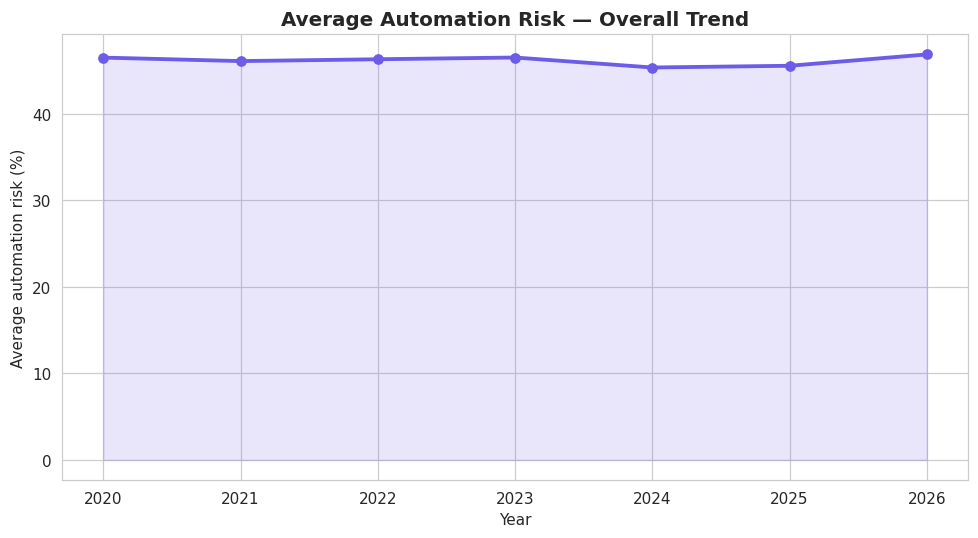

Change in average risk from 2020 to 2026: +0.36 percentage points


In [14]:
year_overall = df.groupby('year')['automation_risk_percent'].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(year_overall.index, year_overall.values, marker='o', linewidth=2.5, color=PALETTE[0])
ax.fill_between(year_overall.index, year_overall.values, alpha=0.15, color=PALETTE[0])
ax.set_title('Average Automation Risk — Overall Trend', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average automation risk (%)')
plt.tight_layout()
plt.show()

change = year_overall.iloc[-1] - year_overall.iloc[0]
print(f'Change in average risk from 2020 to 2026: {change:+.2f} percentage points')


**Finding:** the trend over the years shows whether occupations' exposure to automation is intensifying as AI evolves (especially from 2024-2025 onward, a period of maturation for agentic AI systems) or stabilizing.


## 9. Question 4 — Is there a difference between countries in AI adoption level and salary impact?


In [15]:
country_stats = df.groupby('country', observed=True).agg(
    avg_adoption=('ai_adoption_level', 'mean'),
    avg_salary_change=('salary_change_percent', 'mean'),
    avg_risk=('automation_risk_percent', 'mean')
).sort_values('avg_adoption', ascending=False).round(2)

country_stats


,avg_adoption,avg_salary_change,avg_risk
country,,,
India,50.46,0.38,46.08
Australia,50.34,0.08,46.57
Singapore,50.01,0.13,46.53
Germany,49.96,0.58,45.76
Japan,49.85,0.10,46.33
UK,49.63,-0.11,46.48
USA,49.38,-0.05,46.09
Brazil,49.37,-0.06,45.61
Canada,49.22,0.01,46.09


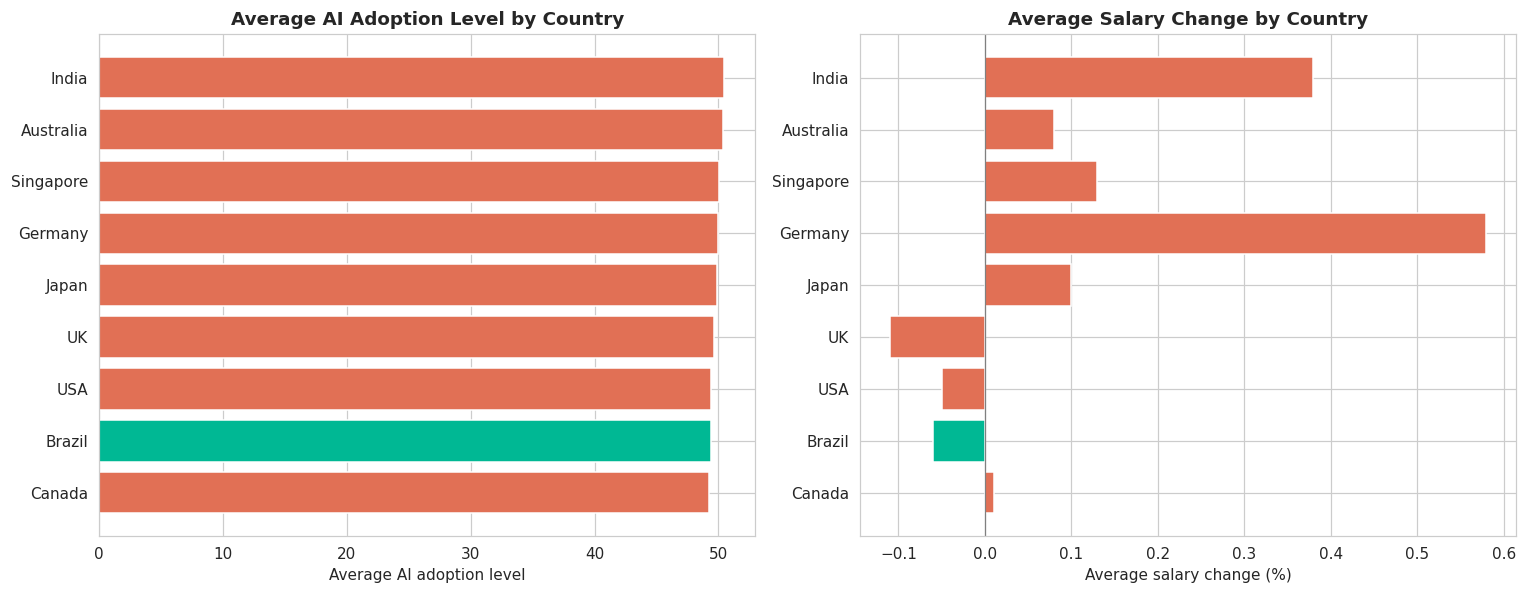

* Highlighted bar (green) = Brazil


In [16]:
highlight = 'Brazil'
colors_country = [PALETTE[1] if c == highlight else PALETTE[3] for c in country_stats.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].barh(country_stats.index[::-1], country_stats['avg_adoption'][::-1],
             color=colors_country[::-1])
axes[0].set_title('Average AI Adoption Level by Country', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average AI adoption level')

axes[1].barh(country_stats.index[::-1], country_stats['avg_salary_change'][::-1],
             color=colors_country[::-1])
axes[1].axvline(0, color='gray', linewidth=0.8)
axes[1].set_title('Average Salary Change by Country', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average salary change (%)')

plt.tight_layout()
plt.show()
print('* Highlighted bar (green) = Brazil')


**Finding:** compare here Brazil's position relative to other countries — whether it's among the ones adopting AI the most (driven by sectors like Technology and Finance, for example) and how that reflects in average salary change compared to countries like the USA, Germany, and India.


## 10. Question 5 — Which occupations have the greatest reskilling urgency?


In [17]:
reskill_role = df.groupby('job_role')['reskilling_urgency_score'].mean().sort_values(ascending=False)

fig = px.bar(
    reskill_role.reset_index(),
    x='reskilling_urgency_score', y='job_role', orientation='h',
    color='reskilling_urgency_score', color_continuous_scale='Teal',
    labels={'reskilling_urgency_score': 'Average reskilling urgency score', 'job_role': 'Occupation'},
    title='Reskilling Urgency by Occupation'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=480)
fig.show()


In [18]:
# Radar comparing the 5 occupations with the highest reskilling urgency across multiple metrics
top5_roles = reskill_role.head(5).index.tolist()
radar_metrics = ['automation_risk_percent', 'skill_gap_index', 'reskilling_urgency_score',
                  'ai_disruption_intensity', 'skill_demand_growth_percent']

radar_df = df[df['job_role'].isin(top5_roles)].groupby('job_role')[radar_metrics].mean()
# Normalizing 0-100 for a fair comparison in the radar
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min()) * 100

fig = go.Figure()
for role in radar_norm.index:
    fig.add_trace(go.Scatterpolar(
        r=radar_norm.loc[role].values.tolist() + [radar_norm.loc[role].values[0]],
        theta=radar_metrics + [radar_metrics[0]],
        fill='toself',
        name=role,
        opacity=0.6
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 100])),
    title='Multidimensional Comparison — Top 5 Occupations by Reskilling Urgency (normalized)',
    height=550
)
fig.show()


**Finding:** this radar chart highlights which occupations simultaneously concentrate high automation risk, a high skill gap, and high reskilling urgency — precisely the profiles that would benefit most from AI-focused training programs.


## 11. Bonus — Building an AI Vulnerability Index

The five previous questions analyzed each metric in isolation. But what if we combined the main impact dimensions into **a single indicator**? The idea here is to move beyond pure descriptive analysis and **build something new from the data**: an *AI Vulnerability Index (AIVI)*, which summarizes, in a single score from 0 to 100, how exposed each occupation is to the transformation brought by Artificial Intelligence.

**How the index is calculated:** we normalize three metrics to the same scale (0-100) and combine them with weights that reflect their relative importance:

$$AIVI = 0.4 \times \text{Automation Risk} \;+\; 0.35 \times \text{Reskilling Urgency} \;+\; 0.25 \times \text{AI Disruption Intensity}$$

Automation risk receives the highest weight (it is the most direct threat to the role), followed by reskilling urgency (measures the required response) and, lastly, disruption intensity (broader context of change in the sector).


In [19]:
from sklearn.preprocessing import MinMaxScaler

# Aggregating by occupation
agg = df.groupby('job_role').agg(
    automation_risk=('automation_risk_percent', 'mean'),
    reskilling_urgency=('reskilling_urgency_score', 'mean'),
    disruption_intensity=('ai_disruption_intensity', 'mean')
).reset_index()

# Normalizing each metric to 0-100
scaler = MinMaxScaler(feature_range=(0, 100))
agg[['risk_norm', 'urgency_norm', 'disruption_norm']] = scaler.fit_transform(
    agg[['automation_risk', 'reskilling_urgency', 'disruption_intensity']]
)

# Weighted index
agg['AIVI'] = (0.40 * agg['risk_norm'] +
               0.35 * agg['urgency_norm'] +
               0.25 * agg['disruption_norm'])

agg = agg.sort_values('AIVI', ascending=False).reset_index(drop=True)
agg.index += 1  # ranking starting at 1

agg[['job_role', 'AIVI', 'automation_risk', 'reskilling_urgency', 'disruption_intensity']].round(2)


,job_role,AIVI,automation_risk,reskilling_urgency,disruption_intensity
1,Truck Driver,100.00,60.74,41.81,29.72
2,Customer Support Rep,97.45,59.85,41.60,29.47
3,Mechanical Engineer,42.90,45.40,35.67,22.79
4,HR Manager,42.10,45.09,35.44,22.99
5,Teacher,42.08,45.14,35.72,22.50
6,Marketing Specialist,41.72,45.44,35.66,22.17
7,Accountant,41.49,44.98,35.32,22.97
8,Financial Analyst,39.83,44.70,34.93,22.97
9,Data Analyst,3.42,35.46,31.61,17.18
10,Software Engineer,0.31,34.85,30.83,17.34


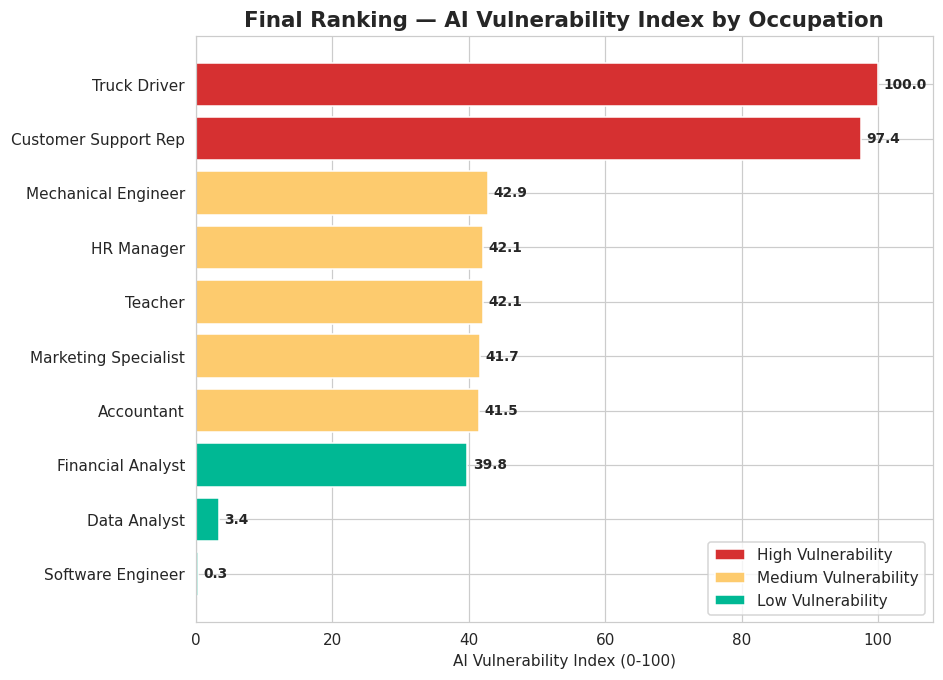

In [20]:
# Classifying into vulnerability buckets
def classify(v):
    if v >= 66:
        return 'High'
    elif v >= 40:
        return 'Medium'
    return 'Low'

agg['vulnerability_bucket'] = agg['AIVI'].apply(classify)

bucket_colors = {'High': '#D63031', 'Medium': '#FDCB6E', 'Low': '#00B894'}
bar_colors = agg['vulnerability_bucket'].map(bucket_colors)

fig, ax = plt.subplots(figsize=(10, 6.5))
bars = ax.barh(agg['job_role'][::-1], agg['AIVI'][::-1], color=bar_colors[::-1])

for bar, v in zip(bars, agg['AIVI'][::-1]):
    ax.text(v + 0.8, bar.get_y() + bar.get_height()/2, f'{v:.1f}', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('AI Vulnerability Index (0-100)')
ax.set_title('Final Ranking — AI Vulnerability Index by Occupation', fontsize=14, fontweight='bold')
ax.set_xlim(0, agg['AIVI'].max() + 8)

# Custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=f'{f} Vulnerability') for f, c in bucket_colors.items()]
ax.legend(handles=legend_elements, loc='lower right', frameon=True)

fig.subplots_adjust(top=0.92, bottom=0.10, left=0.28, right=0.95)
plt.show()


In [21]:
top3_vulnerable = agg.head(3)[['job_role', 'AIVI']]
top3_safe = agg.tail(3)[['job_role', 'AIVI']].iloc[::-1]

print('TOP 3 MOST VULNERABLE OCCUPATIONS TO AI')
for _, row in top3_vulnerable.iterrows():
    print(f'   {row.job_role}: {row.AIVI:.1f} / 100')

print()
print('TOP 3 SAFEST OCCUPATIONS FROM AI')
for _, row in top3_safe.iterrows():
    print(f'   {row.job_role}: {row.AIVI:.1f} / 100')


TOP 3 MOST VULNERABLE OCCUPATIONS TO AI
   Truck Driver: 100.0 / 100
   Customer Support Rep: 97.4 / 100
   Mechanical Engineer: 42.9 / 100

TOP 3 SAFEST OCCUPATIONS FROM AI
   Software Engineer: 0.3 / 100
   Data Analyst: 3.4 / 100
   Financial Analyst: 39.8 / 100


**Finding:** the index confirms and reinforces the pattern observed in the previous questions, now as a single, easy-to-communicate combined metric: **Truck Driver** and **Customer Support Rep** lead as the most vulnerable occupations to AI, while **Software Engineer** and **Data Analyst** appear as the safest in the short/medium term — precisely the areas this very project is steering you toward.

### Practical Recommendations by Profile

- **If you're in a High vulnerability occupation:** prioritize developing skills that complement AI rather than compete with it — supervising automated systems, handling complex exceptions, or a gradual transition to hybrid roles (e.g., a driver could move into logistics and autonomous fleet management).
- **If you're in a Medium vulnerability occupation:** now is the time to become "AI-fluent" in your own field — using AI tools as part of your workflow, not as a threat.
- **If you're in a Low vulnerability occupation (like Data Analysis!):** it's still worth continuing to evolve — technical fields change fast, and those who understand data + AI today tend to become increasingly relevant, not less.


## 12. Conclusions

Recapping the 5 research questions:

1. **Replacement risk:** Truck Driver (60.7%) and Customer Support Rep (59.9%) lead in automation risk, while Data Analyst (35.5%) and Software Engineer (34.9%) are the least exposed. By industry the variation is small (45.6% to 47.0%) — risk depends much more on occupation than on sector.
2. **AI and salary:** the correlation between AI adoption and salary change is essentially null (r ≈ 0.000). In this dataset, adopting more AI is not associated with earning more or less.
3. **Evolution 2020-2026:** the overall average risk stayed stable (a change of only +0.36 p.p. over the period), but with opposite trajectories by sector — Technology decreased (-2.5 p.p.) while Retail and Energy increased (+3.0 and +2.0 p.p., respectively).
4. **Differences between countries:** countries are quite close in AI adoption and automation risk. Brazil is at the group average for adoption (49.37) and has a stable salary change (-0.06%), on par with the USA and UK.
5. **Reskilling urgency:** follows the same pattern as automation risk — Truck Driver and Customer Support Rep are the occupations that would most need training/career transition programs.
6. **AI Vulnerability Index (bonus):** combining the three dimensions above into a single indicator, Truck Driver and Customer Support Rep are confirmed as the most vulnerable occupations, and Software Engineer/Data Analyst as the safest.

### Final Message

Artificial Intelligence does not affect all occupations in the same way — the impact is much more tied to **the type of task performed** (repetitive vs. analytical/creative) than to sector or country. It's also worth highlighting a counterintuitive finding: in this dataset, higher AI adoption did not translate into higher salary gains or losses — suggesting that factors like role and specialization level weigh more heavily than AI exposure itself. Understanding this inequality through data — and translating it into an actionable index — is the first step toward better preparing professionals and companies for this transition.


## 13. Study Limitations

- The dataset is **synthetic** (generated for educational purposes), so absolute values should not be interpreted as official market statistics — but the relative relationships and patterns are useful for learning and data storytelling purposes.
- The analysis is **correlational, not causal**: relationships between AI adoption and salary do not imply direct cause and effect.
- The dataset covers only 10 occupations and 9 countries, a limited sample of the global labor market.
- The **AI Vulnerability Index** is an original construct of this project, with weights defined by reasonable judgment (not statistically calibrated) — other weightings are possible and may produce slightly different rankings.
